In [ ]:
import h5py                                                                                            
import json                                               
import numpy as np                                                                                     
import matplotlib.pyplot as plt                           
from IPython.display import HTML
from pathlib import Path        
                        
from pim.config import SimConfig                                                                       
from pim.sim import Scene       
from pim.viz import animate_scene, make_waterfall, save_animation  

In [32]:
DATASET_PATH = "../datasets/test1000/dataset.h5"   # ← adjust as needed
                                                                                                         
with h5py.File(DATASET_PATH, "r") as f:
    meta = json.loads(f.attrs["config_json"])                                                          
    print(f"generated : {meta['generated_at']}")          
    print(f"n_samples : {meta['dataset']['n_samples']:,}")                                             
    print()                                               
    for key, ds in f.items():                                                                          
        print(f"  {key:12s}  {str(ds.shape):30s}  {ds.dtype}")

generated : 2026-03-25T15:33:28
n_samples : 1,000

  colors        (1000, 2, 3)                    float32
  is_visible    (1000, 40, 2)                   bool
  n_objects     (1000,)                         uint8
  obs_depth     (1000, 40, 128)                 float32
  obs_id        (1000, 40, 128)                 int8
  obs_intensity  (1000, 40, 128)                 float32
  positions     (1000, 40, 2, 2)                float32
  reflectivities  (1000, 2)                       float32
  seeds         (1000,)                         int64
  velocities    (1000, 40, 2, 2)                float32


In [33]:
def load_sample(path: str, idx: int) -> tuple[Scene, np.ndarray, np.ndarray, np.ndarray]:
    """Reconstruct a Scene and its stored observations from one HDF5 row."""                           
    with h5py.File(path, "r") as f:                                                                    
        cfg = SimConfig(**json.loads(f.attrs["config_json"])["dataset"]["sim"])
        n             = int(f["n_objects"][idx])                                                       
        positions     = f["positions"]    [idx, :, :n, :].astype(np.float64)  # (T, n, 2)              
        velocities    = f["velocities"]   [idx, :, :n, :].astype(np.float64)  # (T, n, 2)
        colors        = f["colors"]       [idx, :n, :]   .astype(np.float64)  # (n, 3)                 
        reflectivities= f["reflectivities"][idx, :n]     .astype(np.float64)  # (n,)  
        obs_depth     = f["obs_depth"]    [idx]          .astype(np.float32)  # (T, R)                 
        obs_id        = f["obs_id"]       [idx]                               # (T, R) int8            
        obs_intensity = f["obs_intensity"][idx]          .astype(np.float32)  # (T, R)                 
                                                                                                        
    scene = Scene(                                                                                     
        positions=positions,
        velocities=velocities,                                                                         
        radii=np.full(n, cfg.radius),
        colors=colors,               
        reflectivities=reflectivities,
        config=cfg,
    )                                                                                                  
    return scene, obs_depth, obs_id, obs_intensity

TypeError: SimConfig.__init__() got an unexpected keyword argument 'direction_noise_std'

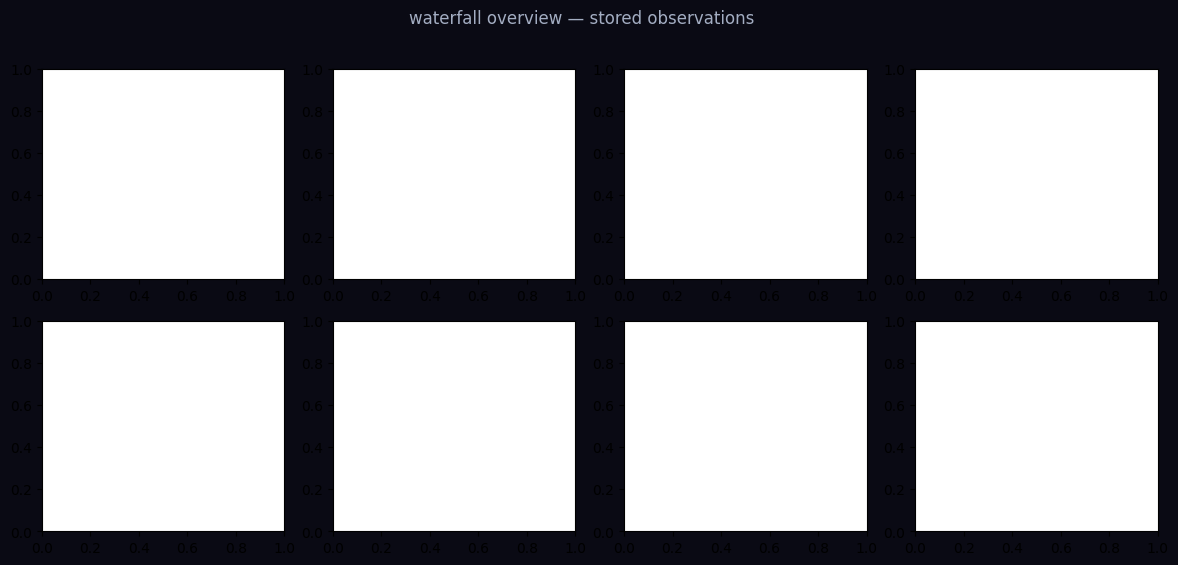

In [34]:
N_SHOW = 8
indices = np.arange(N_SHOW)   # or np.random.choice(n_total, N_SHOW, replace=False)

fig, axes = plt.subplots(2, N_SHOW // 2, figsize=(N_SHOW * 1.8, 6),
                        facecolor="#0a0a14")
fig.suptitle("waterfall overview — stored observations", color="#a3adc2", fontsize=12)

for ax, idx in zip(axes.flat, indices):
    scene, obs_depth, obs_id, obs_intensity = load_sample(DATASET_PATH, idx)                           
    wf = make_waterfall(obs_depth, obs_id, obs_intensity, scene)   # mode="model" by default
    ax.imshow(wf, aspect="auto", origin="upper", interpolation="nearest")                              
    ax.set_title(f"#{idx}  n={scene.positions.shape[1]}", color="#a3adc2", fontsize=10)                
    ax.axis("off")

plt.tight_layout()
plt.show()

In [35]:
idx = 1                                                                                                
scene, obs_depth, obs_id, obs_intensity = load_sample(DATASET_PATH, idx)
anim = animate_scene(scene, obs_depth, obs_id, obs_intensity, title=f"sample {idx}")                   
plt.close()                                                                         
HTML(anim.to_jshtml())

TypeError: SimConfig.__init__() got an unexpected keyword argument 'direction_noise_std'

In [ ]:
out_dir = Path("outputs/samples")                                                                      
out_dir.mkdir(parents=True, exist_ok=True)
                                                                                                        
for idx in range(5):                                                                                   
    scene, obs_depth, obs_id, obs_intensity = load_sample(DATASET_PATH, idx)
    anim = animate_scene(scene, obs_depth, obs_id, obs_intensity, title=f"sample {idx}")
    save_animation(anim, str(out_dir / f"sample_{idx:04d}.gif"), fps=20)                               
    plt.close() 